# Предобработка данных: комплексная лабораторная работа

**Датасет:** Синтетические медицинские данные пациентов кардиологического отделения + sklearn `breast_cancer` для отбора признаков.

**Задачи:**
1. Устранение пропусков в данных
2. Кодирование категориальных признаков
3. Нормализация числовых признаков
4. Масштабирование признаков (3 способа)
5. Обработка выбросов (удаление + замена)
6. Обработка нестандартного признака (дата-время)
7. Отбор признаков (filter, wrapper, embedded)

In [1]:
# Установим необходимые библиотеки в текущей среде
%pip install numpy pandas matplotlib seaborn scipy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Все библиотеки загружены успешно.')


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Все библиотеки загружены успешно.


---
## 0. Создание медицинского датасета

Генерируем реалистичный набор данных пациентов кардиологического отделения с:
- числовыми признаками (возраст, давление, холестерин, глюкоза, ИМТ, ЧСС)
- категориальными признаками (пол, группа крови, статус курения, тип боли в груди)
- нестандартным признаком (дата госпитализации)
- искусственно внесёнными пропусками

In [2]:
np.random.seed(42)
n = 600

# --- Числовые признаки ---
age = np.random.normal(55, 12, n).clip(20, 90).astype(int)
systolic_bp = np.random.normal(130, 20, n).clip(80, 220).round(1)
cholesterol = np.random.normal(220, 45, n).clip(100, 400).round(1)
glucose = np.random.exponential(scale=30, size=n) + 70  # скошенное распределение
glucose = glucose.clip(60, 350).round(1)
bmi = np.random.normal(27, 5, n).clip(15, 50).round(1)
heart_rate = np.random.normal(75, 12, n).clip(40, 150).astype(int)

# Добавим выбросы вручную
cholesterol[0:5] = [580, 560, 550, 600, 590]
systolic_bp[5:9] = [260, 270, 255, 265]
glucose[10:14] = [450, 480, 500, 460]

# --- Категориальные признаки ---
gender = np.random.choice(['Male', 'Female'], n, p=[0.6, 0.4])
blood_type = np.random.choice(['A', 'B', 'AB', 'O'], n, p=[0.35, 0.25, 0.10, 0.30])
smoking = np.random.choice(['never', 'former', 'current'], n, p=[0.4, 0.35, 0.25])
chest_pain = np.random.choice(
    ['typical_angina', 'atypical_angina', 'non_anginal', 'asymptomatic'], n,
    p=[0.15, 0.25, 0.30, 0.30]
)

# --- Нестандартный признак: дата госпитализации ---
base_date = pd.Timestamp('2022-01-01')
admission_date = [base_date + pd.Timedelta(days=int(d)) 
                  for d in np.random.uniform(0, 730, n)]

# --- Целевой признак ---
# вероятность сердечного заболевания зависит от признаков
logit = (-3 + 0.03 * age + 0.01 * systolic_bp + 0.005 * cholesterol 
         + 0.01 * glucose - 0.05 * heart_rate + 0.1 * bmi
         + 0.5 * (smoking == 'current').astype(int)
         + 0.3 * (gender == 'Male').astype(int))
prob = 1 / (1 + np.exp(-logit))
target = (np.random.uniform(0, 1, n) < prob).astype(int)

df = pd.DataFrame({
    'age': age.astype(float),
    'systolic_bp': systolic_bp,
    'cholesterol': cholesterol,
    'glucose': glucose,
    'bmi': bmi,
    'heart_rate': heart_rate.astype(float),
    'gender': gender,
    'blood_type': blood_type,
    'smoking': smoking,
    'chest_pain': chest_pain,
    'admission_date': admission_date,
    'heart_disease': target
})

# --- Внесение пропусков ---
np.random.seed(7)
for col, frac in [('age', 0.05), ('cholesterol', 0.10), ('glucose', 0.08),
                   ('bmi', 0.12), ('smoking', 0.06), ('blood_type', 0.04)]:
    mask = np.random.choice(n, size=int(n * frac), replace=False)
    df.loc[mask, col] = np.nan

print(f'Размер датасета: {df.shape}')
df.head(10)

Размер датасета: (600, 12)


,age,systolic_bp,cholesterol,glucose,bmi,heart_rate,gender,blood_type,smoking,chest_pain,admission_date,heart_disease
0,60.0,145.1,580.0,90.4,30.4,63.0,Female,O,never,typical_angina,2022-11-13,1
1,53.0,111.6,560.0,106.3,NaN,66.0,Female,A,former,asymptomatic,2023-08-07,1
2,62.0,147.4,550.0,218.1,NaN,78.0,Female,O,current,atypical_angina,2023-06-24,1
3,73.0,157.1,600.0,74.2,29.3,72.0,Male,O,current,atypical_angina,2022-11-08,1
4,52.0,138.3,590.0,79.6,18.4,48.0,Male,A,former,non_anginal,2022-09-01,1
5,52.0,260.0,221.8,NaN,NaN,49.0,Male,B,former,typical_angina,2022-08-20,1
6,73.0,270.0,188.4,86.4,33.0,67.0,Male,A,never,non_anginal,2023-07-20,1
7,64.0,255.0,190.2,85.9,22.1,80.0,Male,O,former,typical_angina,2022-02-08,1
8,49.0,265.0,156.9,141.5,24.7,42.0,Female,B,current,non_anginal,2022-01-10,1
9,61.0,159.9,NaN,107.6,29.3,69.0,Female,AB,never,atypical_angina,2023-08-04,1


In [3]:
print('Типы данных:')
print(df.dtypes)
print(f'\nРаспределение целевого признака:\n{df["heart_disease"].value_counts()}')

Типы данных:
age                      float64
systolic_bp              float64
cholesterol              float64
glucose                  float64
bmi                      float64
heart_rate               float64
gender                       str
blood_type                   str
smoking                      str
chest_pain                   str
admission_date    datetime64[us]
heart_disease              int64
dtype: object

Распределение целевого признака:
heart_disease
1    472
0    128
Name: count, dtype: int64


Пропуски в данных:


,Кол-во пропусков,Доля (%)
age,30,5.0
cholesterol,60,10.0
glucose,48,8.0
bmi,72,12.0
blood_type,24,4.0
smoking,36,6.0


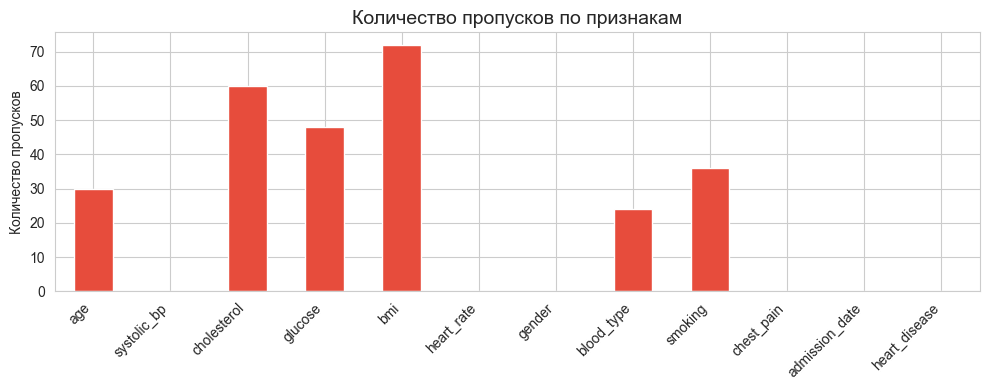

In [4]:
# Пропуски в данных
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_info = pd.DataFrame({'Кол-во пропусков': missing, 'Доля (%)': missing_pct})
missing_info = missing_info[missing_info['Кол-во пропусков'] > 0]
print('Пропуски в данных:')
display(missing_info)

# Визуализация пропусков
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in df.isnull().sum()]
df.isnull().sum().plot(kind='bar', ax=ax, color=colors)
ax.set_title('Количество пропусков по признакам', fontsize=14)
ax.set_ylabel('Количество пропусков')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 1. Устранение пропусков в данных

### 1.1 Удаление строк с пропусками (для демонстрации)

In [5]:
df_dropped = df.dropna()
print(f'До удаления:  {df.shape[0]} строк')
print(f'После удаления: {df_dropped.shape[0]} строк')
print(f'Потеряно: {df.shape[0] - df_dropped.shape[0]} строк ({(1 - df_dropped.shape[0]/df.shape[0])*100:.1f}%)')
print('\nВывод: потеря данных значительна, лучше использовать импьютацию.')

До удаления:  600 строк
После удаления: 370 строк
Потеряно: 230 строк (38.3%)

Вывод: потеря данных значительна, лучше использовать импьютацию.


### 1.2 Заполнение числовых признаков средним и медианой

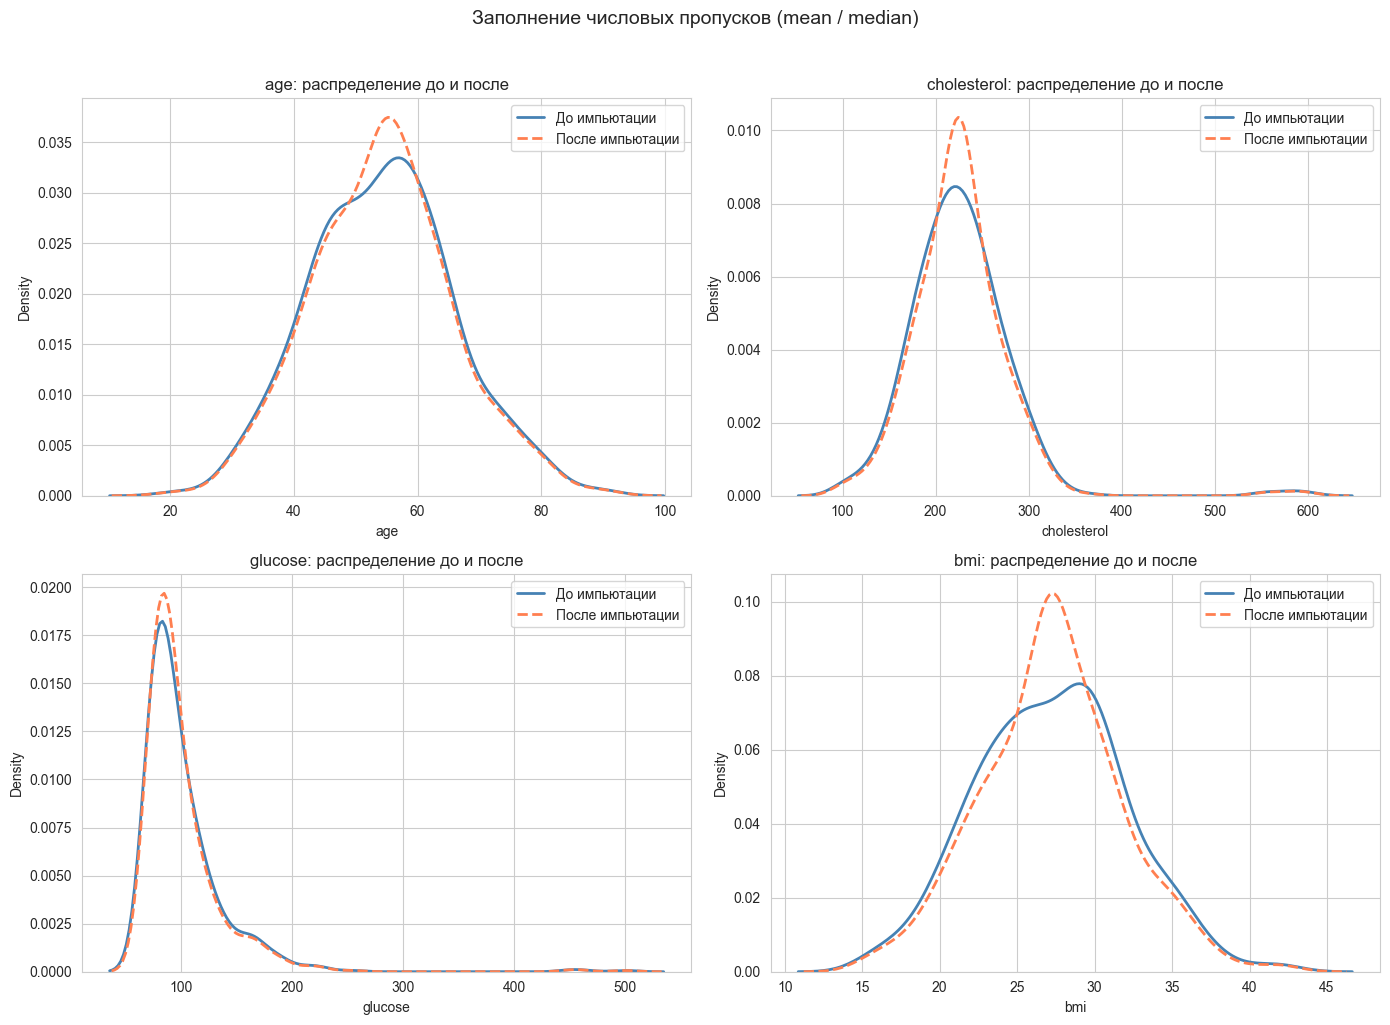

Оставшиеся пропуски (числовые): 0


In [6]:
df_imp = df.copy()
num_cols_with_na = ['age', 'cholesterol', 'glucose', 'bmi']

# Заполнение средним (age, cholesterol) и медианой (glucose - скошенное, bmi)
imp_mean = SimpleImputer(strategy='mean')
imp_median = SimpleImputer(strategy='median')

df_imp[['age', 'cholesterol']] = imp_mean.fit_transform(df_imp[['age', 'cholesterol']])
df_imp[['glucose', 'bmi']] = imp_median.fit_transform(df_imp[['glucose', 'bmi']])

# Визуализация: сравнение распределений до и после импьютации
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), num_cols_with_na):
    sns.kdeplot(df[col].dropna(), ax=ax, label='До импьютации', linewidth=2, color='steelblue')
    sns.kdeplot(df_imp[col], ax=ax, label='После импьютации', linewidth=2, linestyle='--', color='coral')
    ax.set_title(f'{col}: распределение до и после', fontsize=12)
    ax.legend()
plt.suptitle('Заполнение числовых пропусков (mean / median)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Оставшиеся пропуски (числовые):', df_imp[num_cols_with_na].isnull().sum().sum())

### 1.3 Заполнение числовых признаков методом KNN

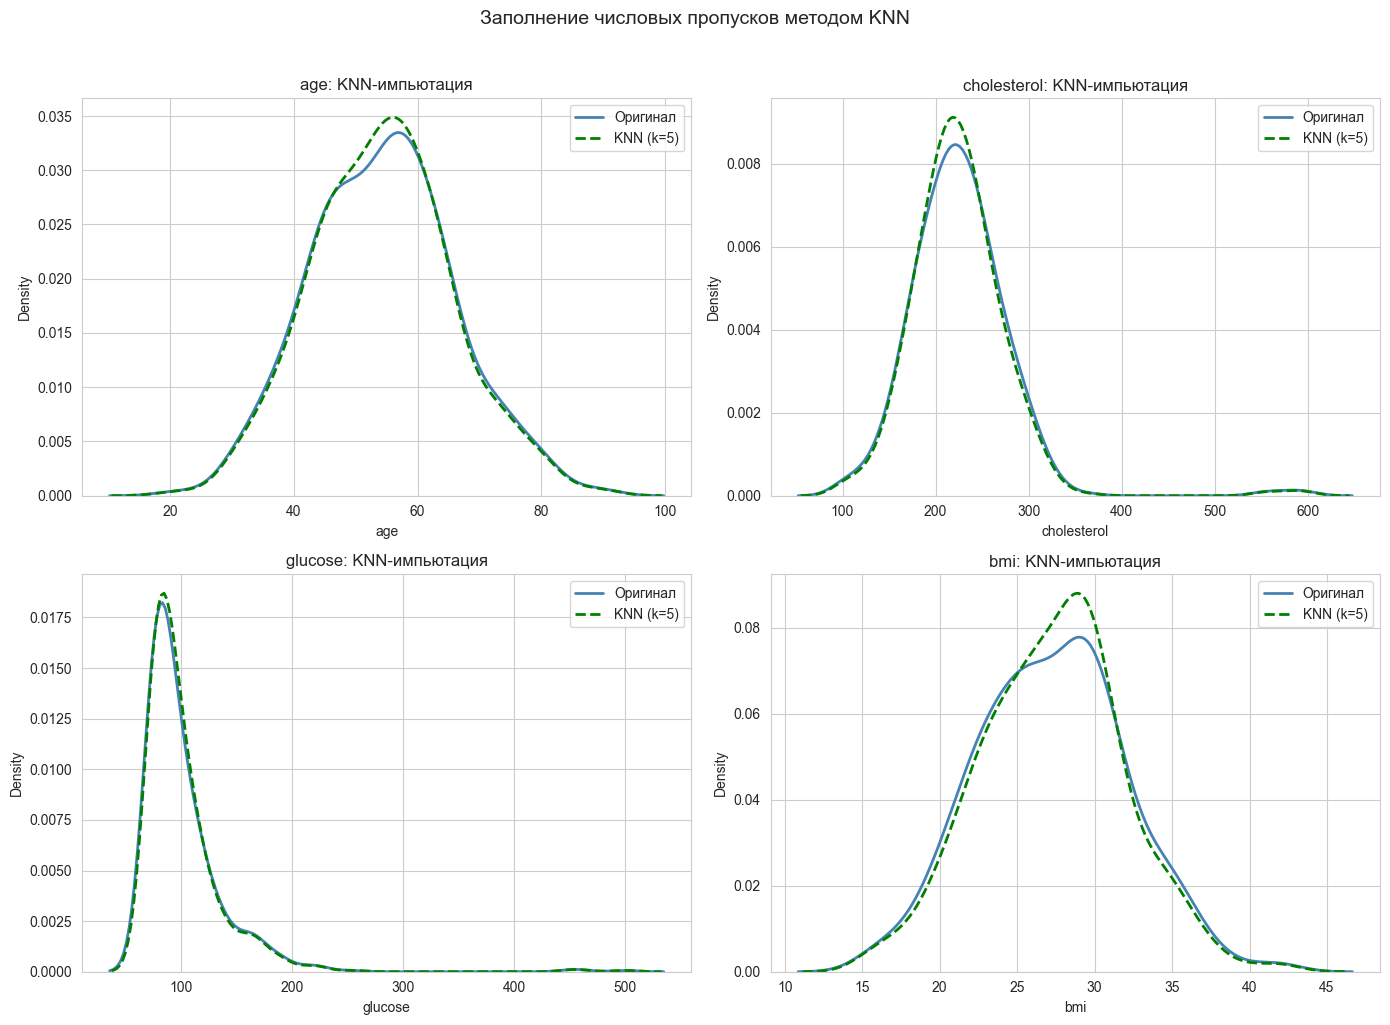

Оставшиеся пропуски (числовые): 0


In [7]:
df_knn = df.copy()
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn[num_cols_with_na] = knn_imputer.fit_transform(df_knn[num_cols_with_na])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), num_cols_with_na):
    sns.kdeplot(df[col].dropna(), ax=ax, label='Оригинал', linewidth=2, color='steelblue')
    sns.kdeplot(df_knn[col], ax=ax, label='KNN (k=5)', linewidth=2, linestyle='--', color='green')
    ax.set_title(f'{col}: KNN-импьютация', fontsize=12)
    ax.legend()
plt.suptitle('Заполнение числовых пропусков методом KNN', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Оставшиеся пропуски (числовые):', df_knn[num_cols_with_na].isnull().sum().sum())

### 1.4 Заполнение категориальных признаков модой

До импьютации:
  smoking: 36 пропусков
  blood_type: 24 пропусков

После импьютации (мода):
  smoking: 0 пропусков
  blood_type: 0 пропусков


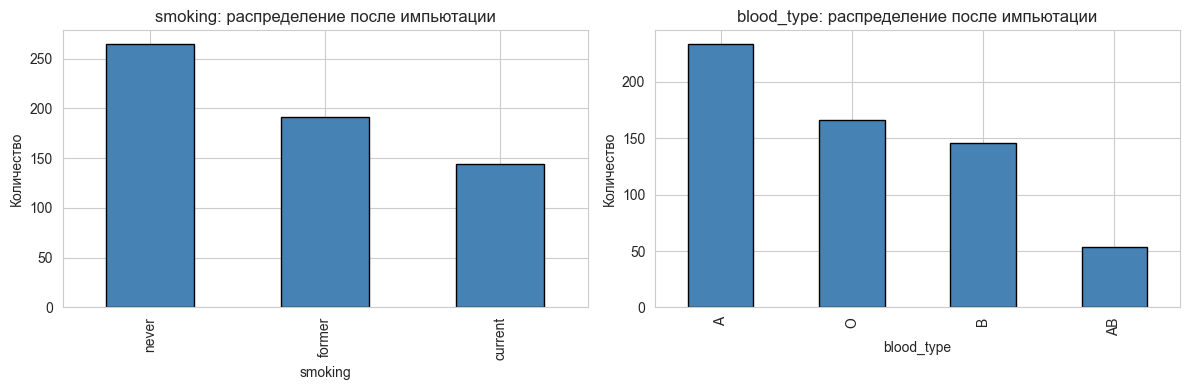


Итого пропусков в датасете: 0


In [8]:
cat_cols_with_na = ['smoking', 'blood_type']

print('До импьютации:')
for col in cat_cols_with_na:
    print(f'  {col}: {df_imp[col].isnull().sum()} пропусков')

imp_mode = SimpleImputer(strategy='most_frequent')
df_imp[cat_cols_with_na] = imp_mode.fit_transform(df_imp[cat_cols_with_na])

print('\nПосле импьютации (мода):')
for col in cat_cols_with_na:
    print(f'  {col}: {df_imp[col].isnull().sum()} пропусков')

# Визуализация распределения категорий после заполнения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, cat_cols_with_na):
    df_imp[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}: распределение после импьютации', fontsize=12)
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

print(f'\nИтого пропусков в датасете: {df_imp.isnull().sum().sum()}')

---
## 2. Кодирование категориальных признаков

Работаем с датасетом после устранения пропусков (`df_imp`).

In [9]:
df_enc = df_imp.copy()
cat_cols = ['gender', 'blood_type', 'smoking', 'chest_pain']
print('Категориальные признаки и их уникальные значения:')
for col in cat_cols:
    print(f'  {col}: {df_enc[col].unique()}')

Категориальные признаки и их уникальные значения:
  gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
  blood_type: <StringArray>
['O', 'A', 'B', 'AB']
Length: 4, dtype: str
  smoking: <StringArray>
['never', 'former', 'current']
Length: 3, dtype: str
  chest_pain: <StringArray>
['typical_angina', 'asymptomatic', 'atypical_angina', 'non_anginal']
Length: 4, dtype: str


### 2.1 Label Encoding (gender — бинарный признак)

In [10]:
le = LabelEncoder()
df_enc['gender_le'] = le.fit_transform(df_enc['gender'])

print('Label Encoding для gender:')
print(f'  Классы: {le.classes_}')
print(f'  Коды:   {le.transform(le.classes_)}')
display(df_enc[['gender', 'gender_le']].drop_duplicates().reset_index(drop=True))

Label Encoding для gender:
  Классы: ['Female' 'Male']
  Коды:   [0 1]


,gender,gender_le
0,Female,0
1,Male,1


### 2.2 Ordinal Encoding (smoking — есть естественный порядок: never < former < current)

In [11]:
oe = OrdinalEncoder(categories=[['never', 'former', 'current']])
df_enc['smoking_ord'] = oe.fit_transform(df_enc[['smoking']])

print('Ordinal Encoding для smoking (с учётом порядка):')
display(df_enc[['smoking', 'smoking_ord']].drop_duplicates().sort_values('smoking_ord').reset_index(drop=True))

Ordinal Encoding для smoking (с учётом порядка):


,smoking,smoking_ord
0,never,0.0
1,former,1.0
2,current,2.0


### 2.3 One-Hot Encoding (blood_type, chest_pain — нет естественного порядка)

In [12]:
df_enc = pd.get_dummies(df_enc, columns=['blood_type', 'chest_pain'], 
                         prefix=['blood', 'pain'], drop_first=False)

# Покажем результат
ohe_cols = [c for c in df_enc.columns if c.startswith('blood_') or c.startswith('pain_')]
print(f'Новые OHE-столбцы ({len(ohe_cols)}):')
for c in ohe_cols:
    print(f'  {c}: {df_enc[c].value_counts().to_dict()}')

display(df_enc[ohe_cols].head(10))

Новые OHE-столбцы (8):
  blood_A: {False: 366, True: 234}
  blood_AB: {False: 546, True: 54}
  blood_B: {False: 454, True: 146}
  blood_O: {False: 434, True: 166}
  pain_asymptomatic: {False: 419, True: 181}
  pain_atypical_angina: {False: 446, True: 154}
  pain_non_anginal: {False: 422, True: 178}
  pain_typical_angina: {False: 513, True: 87}


,blood_A,blood_AB,blood_B,blood_O,pain_asymptomatic,pain_atypical_angina,pain_non_anginal,pain_typical_angina
0,False,False,False,True,False,False,False,True
1,True,False,False,False,True,False,False,False
2,False,False,False,True,False,True,False,False
3,False,False,False,True,False,True,False,False
4,True,False,False,False,False,False,True,False
5,False,False,True,False,False,False,False,True
6,True,False,False,False,False,False,True,False
7,False,False,False,True,False,False,False,True
8,False,False,True,False,False,False,True,False
9,False,True,False,False,False,True,False,False


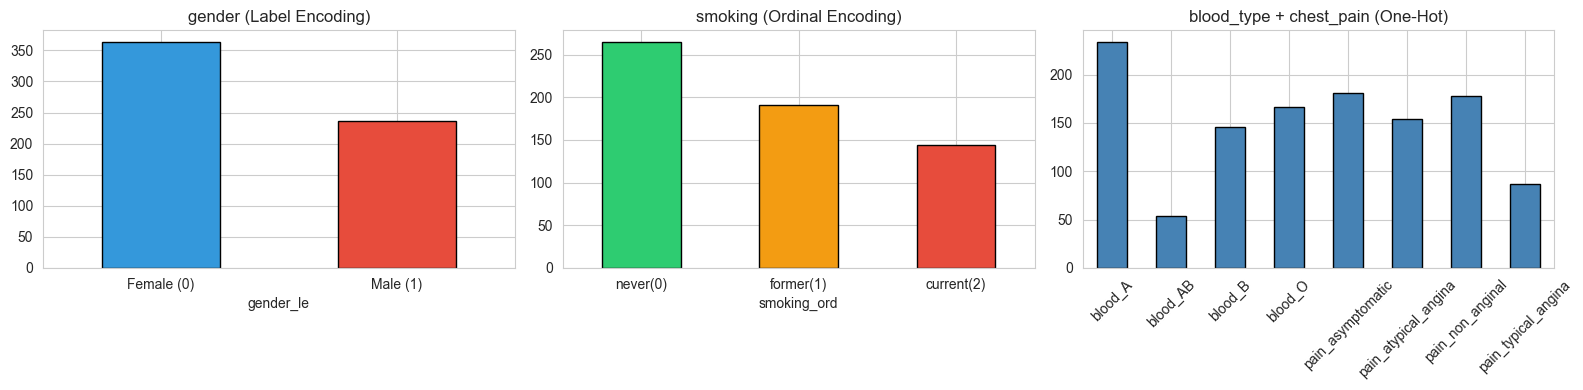

In [13]:
# Сводная визуализация: закодированные категории
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_enc['gender_le'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c'], edgecolor='black')
axes[0].set_title('gender (Label Encoding)', fontsize=12)
axes[0].set_xticklabels(['Female (0)', 'Male (1)'], rotation=0)

df_enc['smoking_ord'].value_counts().sort_index().plot(kind='bar', ax=axes[1], 
    color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='black')
axes[1].set_title('smoking (Ordinal Encoding)', fontsize=12)
axes[1].set_xticklabels(['never(0)', 'former(1)', 'current(2)'], rotation=0)

df_enc[ohe_cols].sum().plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('blood_type + chest_pain (One-Hot)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Нормализация числовых признаков

Применим различные преобразования к `glucose` (имеет скошенное распределение).

In [14]:
def diagnostic_plots(series, title):
    """Гистограмма + Q-Q plot"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Гистограмма
    series.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'{title} — гистограмма', fontsize=12)
    # QQ-plot
    stats.probplot(series.dropna(), dist='norm', plot=axes[1])
    axes[1].set_title(f'{title} — Q-Q plot', fontsize=12)
    plt.tight_layout()
    plt.show()
    # Тест Шапиро-Уилка (на подвыборке чтобы было допустимо)
    sample = series.dropna().sample(min(len(series.dropna()), 500), random_state=42)
    stat, p_val = stats.shapiro(sample)
    print(f'  Shapiro-Wilk: W={stat:.4f}, p={p_val:.6f} — {"нормальное" if p_val > 0.05 else "НЕ нормальное"}')

=== Исходное распределение glucose ===


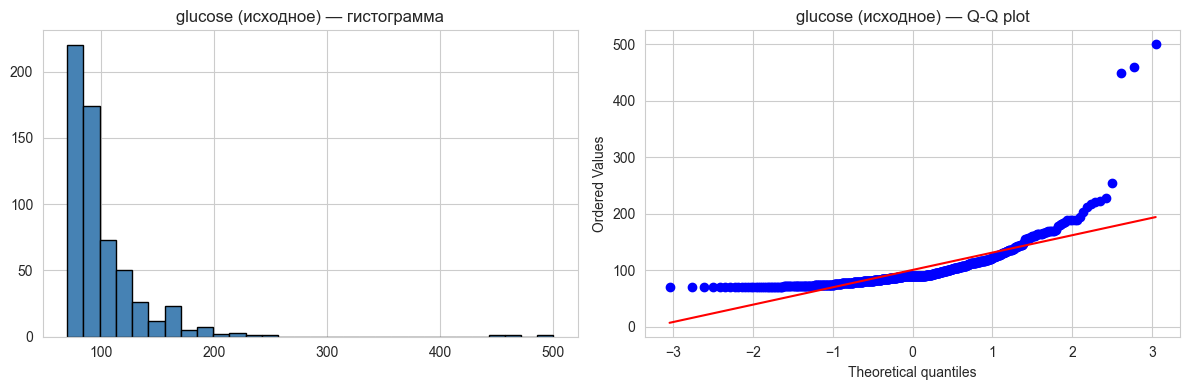

  Shapiro-Wilk: W=0.6274, p=0.000000 — НЕ нормальное


In [15]:
glucose_clean = df_imp['glucose'].copy()

print('=== Исходное распределение glucose ===')
diagnostic_plots(glucose_clean, 'glucose (исходное)')

=== Логарифмическое преобразование ===


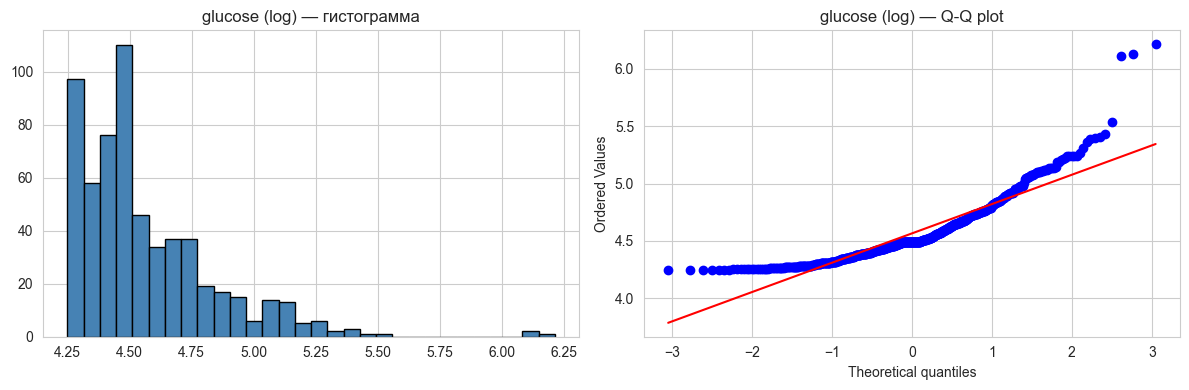

  Shapiro-Wilk: W=0.8611, p=0.000000 — НЕ нормальное


In [16]:
print('=== Логарифмическое преобразование ===')
glucose_log = np.log(glucose_clean)
diagnostic_plots(glucose_log, 'glucose (log)')

=== Квадратный корень ===


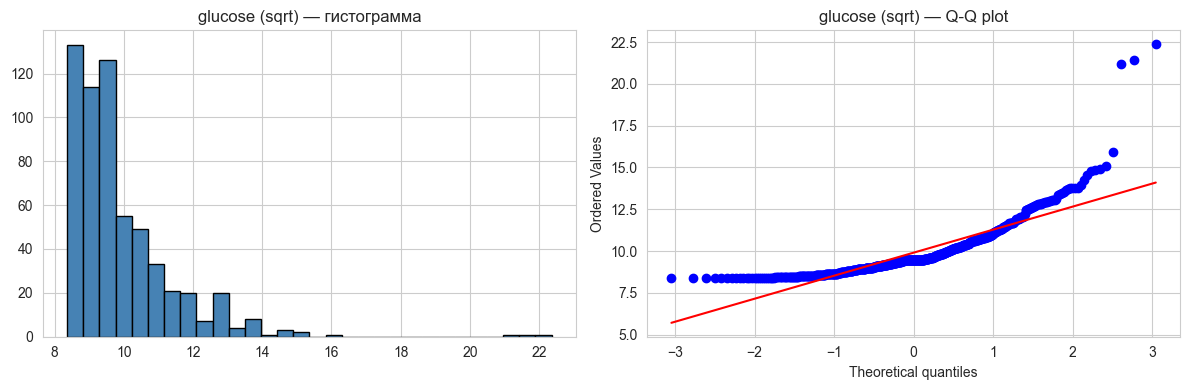

  Shapiro-Wilk: W=0.7677, p=0.000000 — НЕ нормальное


In [17]:
print('=== Квадратный корень ===')
glucose_sqrt = np.sqrt(glucose_clean)
diagnostic_plots(glucose_sqrt, 'glucose (sqrt)')

=== Преобразование Бокса-Кокса ===
  Оптимальное λ = -2.0657


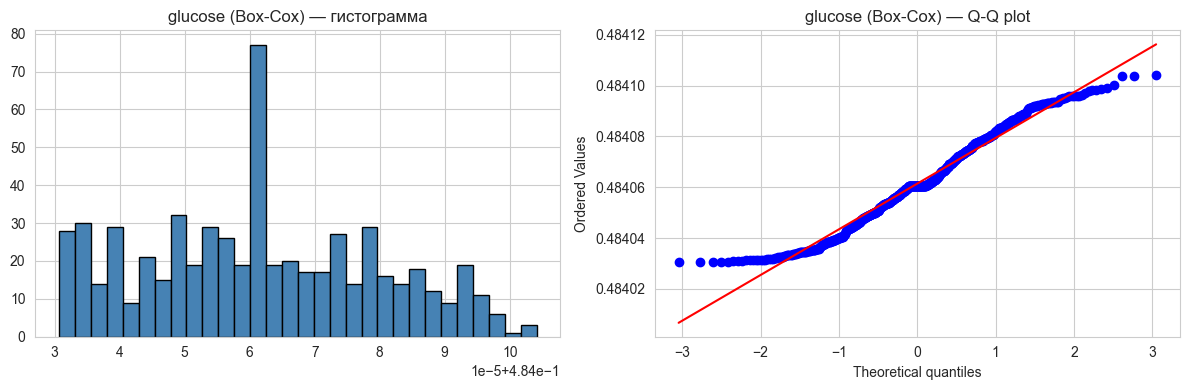

  Shapiro-Wilk: W=0.9721, p=0.000000 — НЕ нормальное


In [18]:
print('=== Преобразование Бокса-Кокса ===')
glucose_boxcox, lam = stats.boxcox(glucose_clean)
print(f'  Оптимальное λ = {lam:.4f}')
diagnostic_plots(pd.Series(glucose_boxcox), 'glucose (Box-Cox)')

=== Преобразование Йео-Джонсона ===
  Оптимальное λ = -2.0925


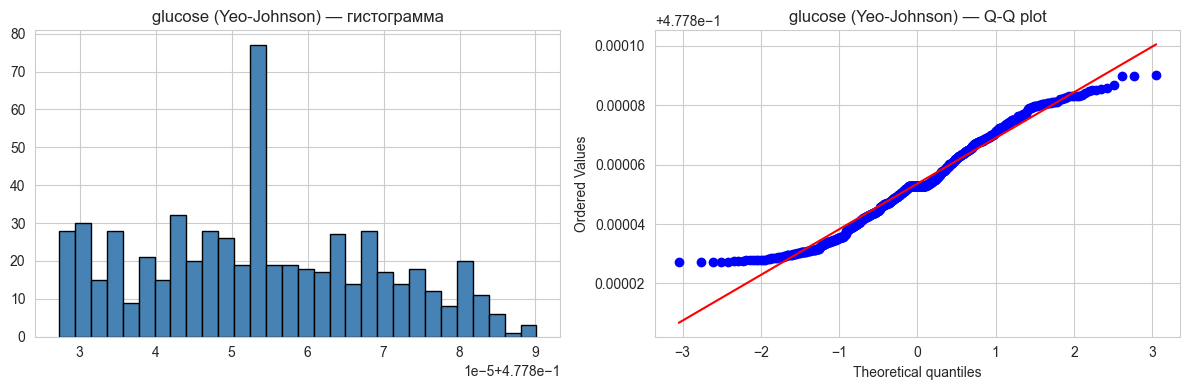

  Shapiro-Wilk: W=0.9720, p=0.000000 — НЕ нормальное


In [19]:
print('=== Преобразование Йео-Джонсона ===')
glucose_yj, lam_yj = stats.yeojohnson(glucose_clean)
print(f'  Оптимальное λ = {lam_yj:.4f}')
diagnostic_plots(pd.Series(glucose_yj), 'glucose (Yeo-Johnson)')

In [20]:
# Сводная таблица результатов нормализации
from scipy.stats import shapiro

transforms = {
    'Исходное': glucose_clean,
    'Log': glucose_log,
    'Sqrt': glucose_sqrt,
    'Box-Cox': pd.Series(glucose_boxcox),
    'Yeo-Johnson': pd.Series(glucose_yj)
}

results = []
for name, s in transforms.items():
    sample = s.dropna().sample(min(len(s.dropna()), 500), random_state=42)
    w, p = shapiro(sample)
    results.append({'Преобразование': name, 'Skewness': s.skew(), 
                    'Kurtosis': s.kurtosis(), 'Shapiro W': w, 'Shapiro p': p})

results_df = pd.DataFrame(results).set_index('Преобразование')
print('Сравнение методов нормализации для glucose:')
display(results_df.style.highlight_max(subset=['Shapiro p'], color='lightgreen')
        .format({'Skewness': '{:.4f}', 'Kurtosis': '{:.4f}', 
                 'Shapiro W': '{:.4f}', 'Shapiro p': '{:.6f}'}))

Сравнение методов нормализации для glucose:


,Skewness,Kurtosis,Shapiro W,Shapiro p
Преобразование,,,,
Исходное,4.9317,39.4693,0.6274,0.000000
Log,1.7859,5.2890,0.8611,0.000000
Sqrt,2.9397,15.4018,0.7677,0.000000
Box-Cox,0.1869,-0.8185,0.9721,0.000000
Yeo-Johnson,0.1883,-0.8192,0.9720,0.000000


---
## 4. Масштабирование признаков (три способа)

Масштабируем числовые признаки тремя способами из лекции:
1. **StandardScaler** (Z-оценка)
2. **MinMaxScaler**
3. **RobustScaler** (по медиане и IQR)

In [21]:
num_cols = ['age', 'systolic_bp', 'cholesterol', 'glucose', 'bmi', 'heart_rate']
X_num = df_imp[num_cols].copy()

print('Статистики ДО масштабирования:')
display(X_num.describe().round(2))

Статистики ДО масштабирования:


,age,systolic_bp,cholesterol,glucose,bmi,heart_rate
count,600.00,600.00,600.00,600.00,600.00,600.00
mean,54.36,132.79,225.87,100.56,27.22,74.34
std,11.30,22.48,52.97,39.28,4.53,12.52
min,20.00,80.00,100.00,70.00,15.00,40.00
25%,47.00,118.90,195.78,79.60,24.30,66.00
50%,54.36,132.35,225.87,89.40,27.20,75.00
75%,61.00,144.90,248.02,108.43,29.92,83.00
max,90.00,270.00,600.00,500.00,42.50,122.00



=== StandardScaler (Z-оценка) ===


,age,systolic_bp,cholesterol,glucose,bmi,heart_rate
count,480.000,480.000,480.000,480.000,480.000,480.000
mean,-0.000,0.000,0.000,-0.000,0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001
min,-2.975,-2.340,-2.335,-0.802,-2.835,-2.710
25%,-0.724,-0.610,-0.565,-0.548,-0.668,-0.665
50%,0.028,-0.010,0.002,-0.298,-0.015,0.043
75%,0.608,0.568,0.396,0.217,0.609,0.672
max,3.143,5.950,6.948,10.385,3.336,3.740



=== MinMaxScaler [0,1] ===


,age,systolic_bp,cholesterol,glucose,bmi,heart_rate
count,480.000,480.000,480.000,480.000,480.000,480.000
mean,0.486,0.282,0.252,0.072,0.459,0.420
std,0.164,0.121,0.108,0.089,0.162,0.155
min,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.368,0.209,0.191,0.023,0.351,0.317
50%,0.491,0.281,0.252,0.045,0.457,0.427
75%,0.586,0.351,0.294,0.091,0.558,0.524
max,1.000,1.000,1.000,1.000,1.000,1.000



=== RobustScaler (медиана/IQR) ===


,age,systolic_bp,cholesterol,glucose,bmi,heart_rate
count,480.000,480.000,480.000,480.000,480.000,480.000
mean,-0.021,0.008,-0.002,0.389,0.012,-0.032
std,0.751,0.849,1.042,1.308,0.784,0.749
min,-2.253,-1.977,-2.432,-0.659,-2.208,-2.059
25%,-0.564,-0.510,-0.590,-0.327,-0.511,-0.529
50%,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.436,0.490,0.410,0.673,0.489,0.471
max,2.337,5.057,7.230,13.954,2.624,2.765


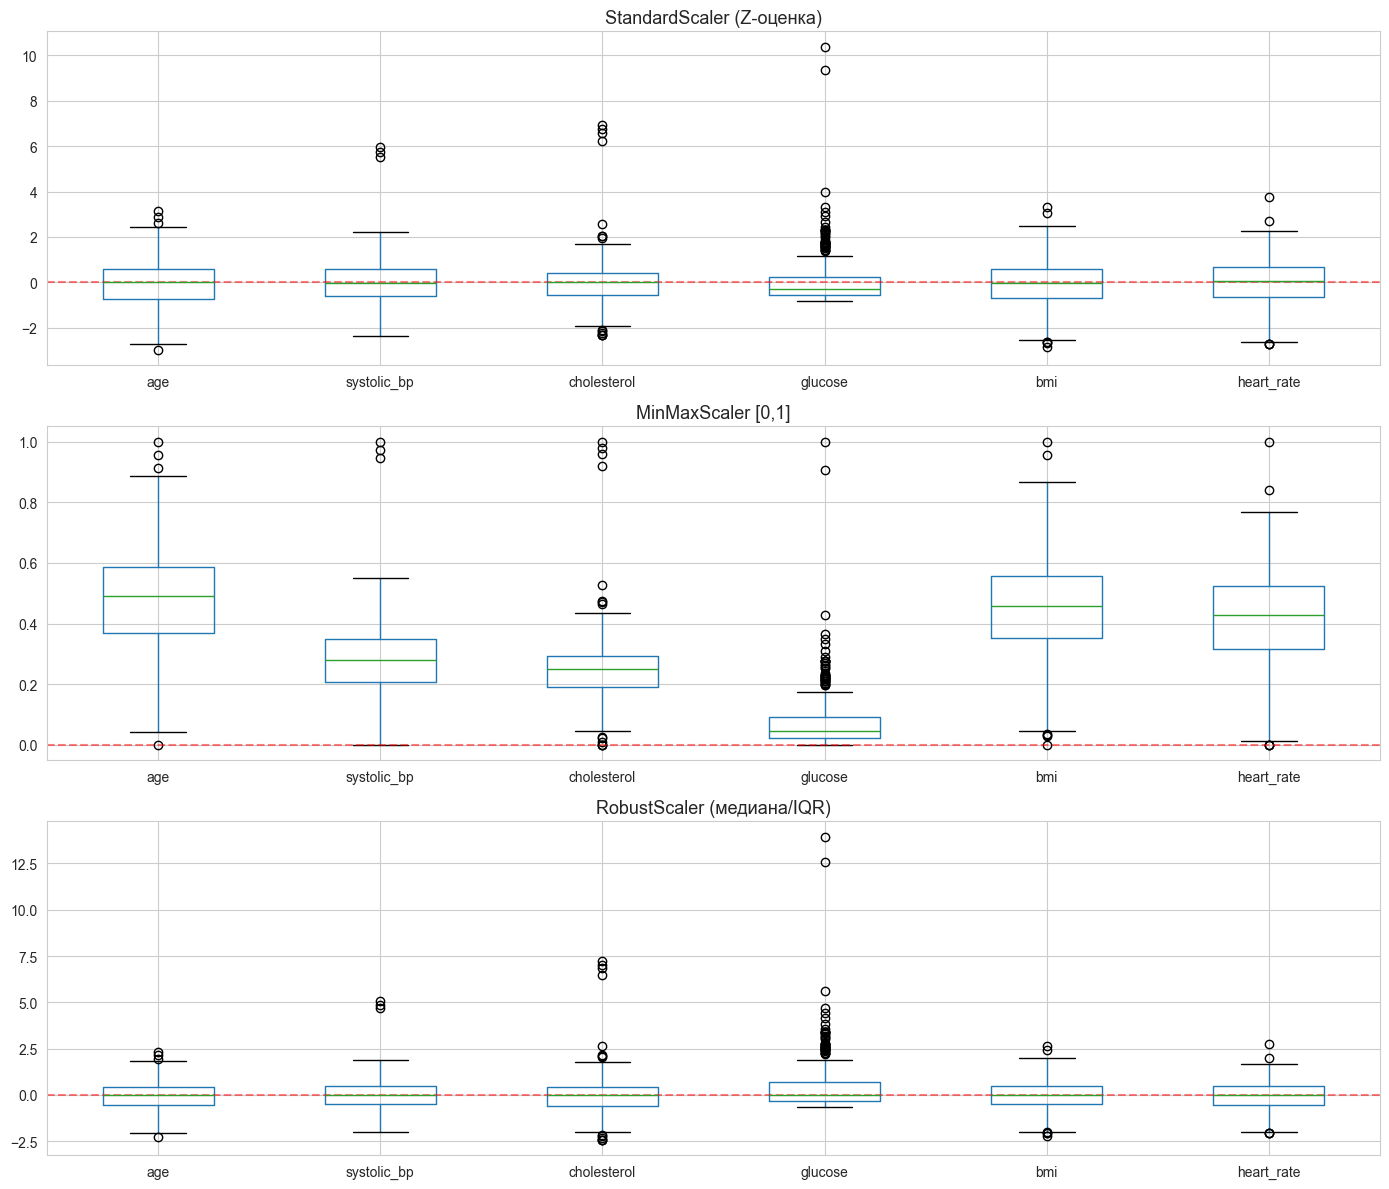

In [22]:
# Разделяем на train/test (масштабируем корректно — fit на train, transform на test)
X_train_num, X_test_num = train_test_split(X_num, test_size=0.2, random_state=42)

scalers = {
    'StandardScaler (Z-оценка)': StandardScaler(),
    'MinMaxScaler [0,1]': MinMaxScaler(),
    'RobustScaler (медиана/IQR)': RobustScaler()
}

fig, axes = plt.subplots(len(scalers), 1, figsize=(14, 4 * len(scalers)))

for idx, (name, scaler) in enumerate(scalers.items()):
    scaler.fit(X_train_num)
    X_scaled = pd.DataFrame(scaler.transform(X_train_num), columns=num_cols)
    
    print(f'\n=== {name} ===')
    display(X_scaled.describe().round(3))
    
    X_scaled.boxplot(ax=axes[idx], vert=True)
    axes[idx].set_title(name, fontsize=13)
    axes[idx].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

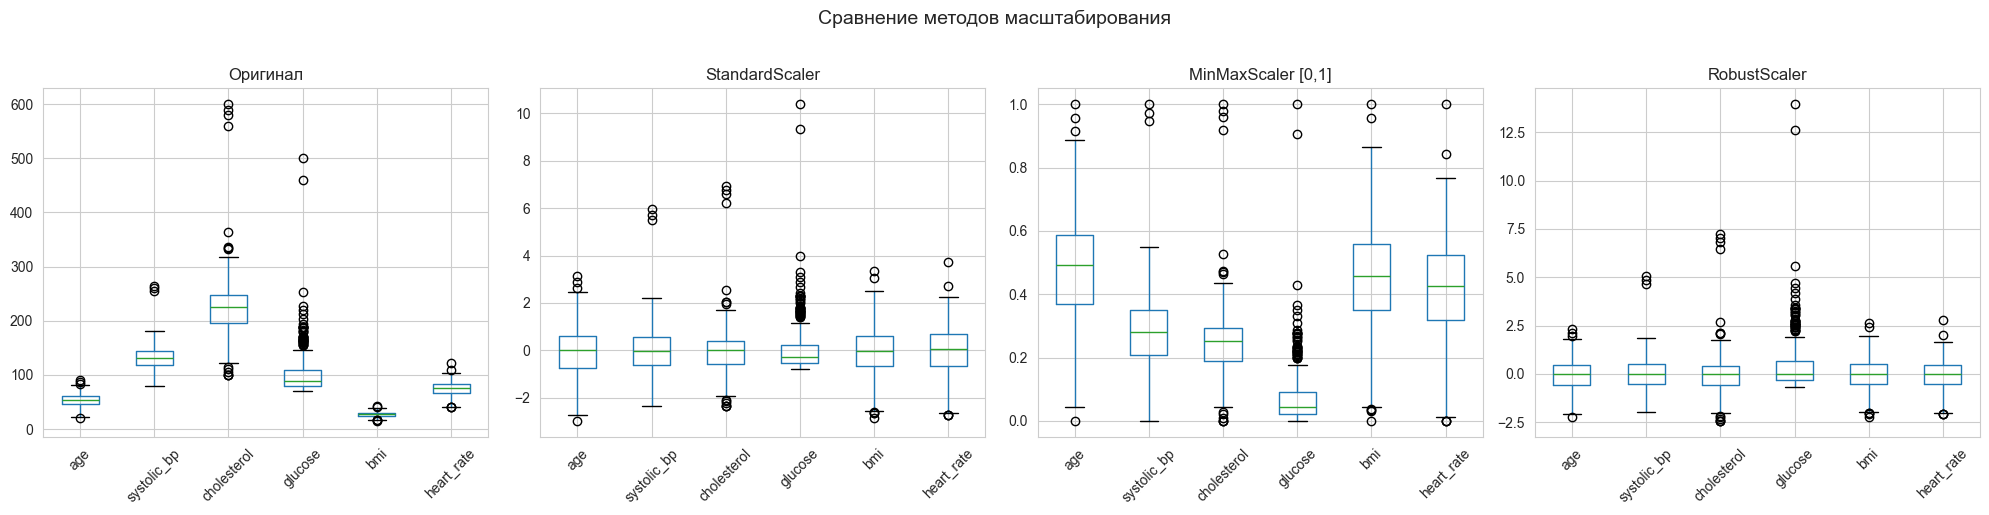

In [23]:
# Наглядное сравнение: boxplot оригинал vs все 3 способа
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)

X_train_num.boxplot(ax=axes[0])
axes[0].set_title('Оригинал', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

for idx, (name, scaler) in enumerate(scalers.items()):
    scaler.fit(X_train_num)
    X_s = pd.DataFrame(scaler.transform(X_train_num), columns=num_cols)
    X_s.boxplot(ax=axes[idx+1])
    axes[idx+1].set_title(name.split('(')[0].strip(), fontsize=12)
    axes[idx+1].tick_params(axis='x', rotation=45)

plt.suptitle('Сравнение методов масштабирования', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Обработка выбросов

### 5.1 Обнаружение выбросов методом IQR


cholesterol: нижняя граница=117.4, верхняя граница=326.4, выбросов=16


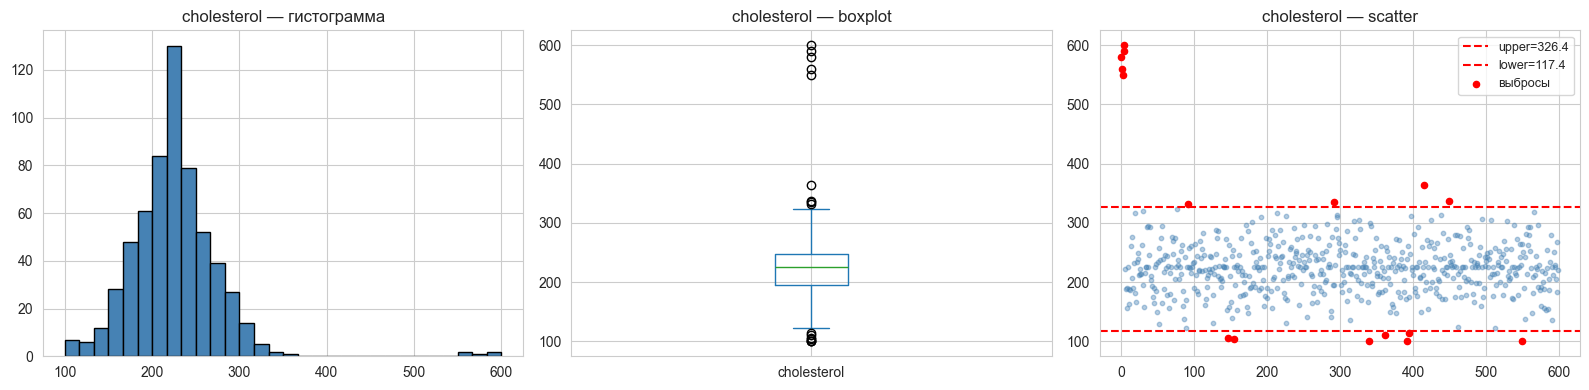


systolic_bp: нижняя граница=79.9, верхняя граница=183.9, выбросов=4


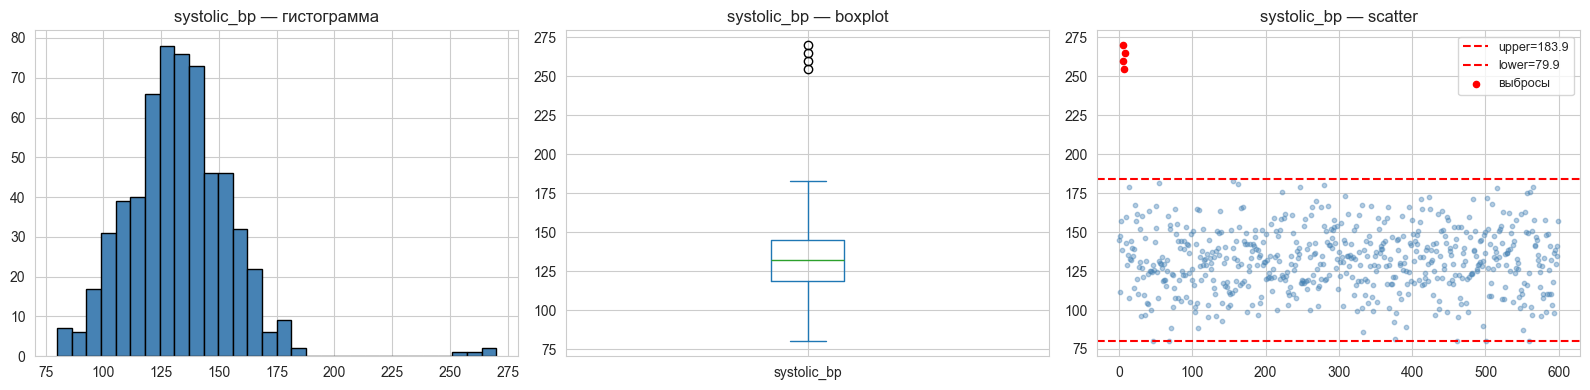


glucose: нижняя граница=36.4, верхняя граница=151.7, выбросов=48


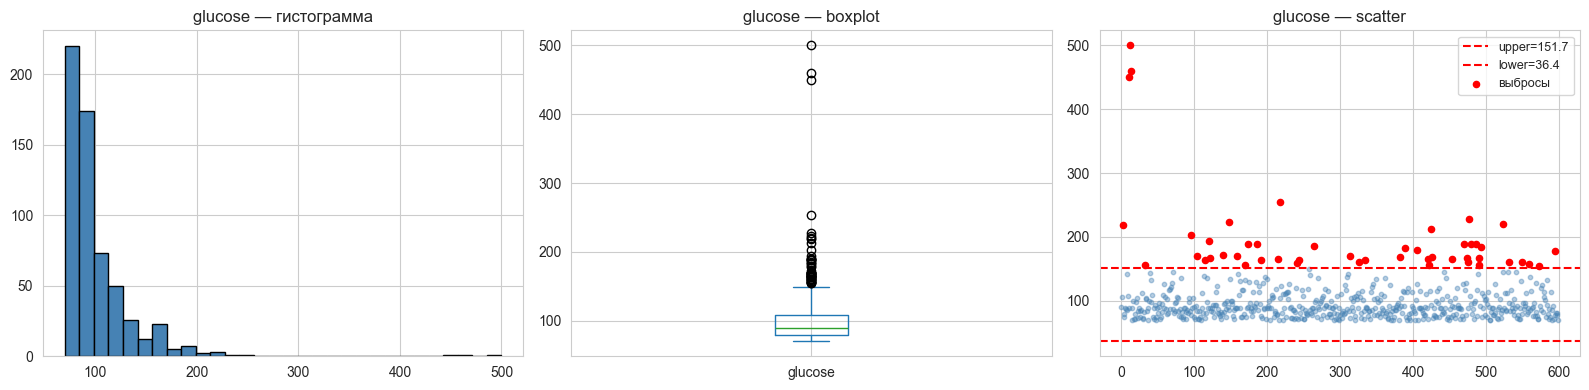

In [24]:
def detect_outliers_iqr(series, k=1.5):
    """Обнаружение выбросов методом IQR"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    outliers_mask = (series < lower) | (series > upper)
    return lower, upper, outliers_mask

def diagnostic_outlier_plots(series, title):
    """Гистограмма + boxplot + scatter"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    series.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'{title} — гистограмма')
    series.plot(kind='box', ax=axes[1])
    axes[1].set_title(f'{title} — boxplot')
    axes[2].scatter(range(len(series)), series, alpha=0.4, s=10, color='steelblue')
    lower, upper, mask = detect_outliers_iqr(series)
    axes[2].axhline(y=upper, color='red', linestyle='--', label=f'upper={upper:.1f}')
    axes[2].axhline(y=lower, color='red', linestyle='--', label=f'lower={lower:.1f}')
    axes[2].scatter(np.where(mask)[0], series[mask], color='red', s=20, label='выбросы')
    axes[2].legend(fontsize=9)
    axes[2].set_title(f'{title} — scatter')
    plt.tight_layout()
    plt.show()

# Обнаружение выбросов для ключевых признаков
outlier_cols = ['cholesterol', 'systolic_bp', 'glucose']
for col in outlier_cols:
    lower, upper, mask = detect_outliers_iqr(df_imp[col])
    print(f'\n{col}: нижняя граница={lower:.1f}, верхняя граница={upper:.1f}, выбросов={mask.sum()}')
    diagnostic_outlier_plots(df_imp[col], col)

### 5.2 Удаление выбросов

cholesterol: удалено 16 выбросов
systolic_bp: удалено 9 выбросов
glucose: удалено 46 выбросов

Итого: было 600 → стало 529 (удалено 71)


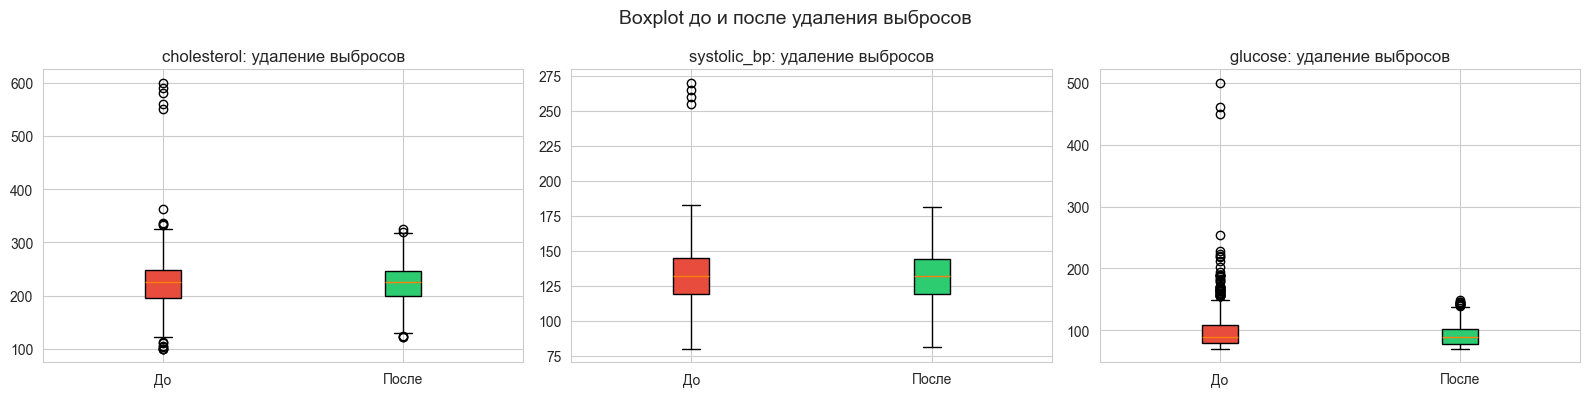

In [25]:
df_no_outliers = df_imp.copy()

total_removed = 0
for col in outlier_cols:
    lower, upper, mask = detect_outliers_iqr(df_no_outliers[col])
    n_before = len(df_no_outliers)
    df_no_outliers = df_no_outliers[~mask]
    removed = n_before - len(df_no_outliers)
    total_removed += removed
    print(f'{col}: удалено {removed} выбросов')

print(f'\nИтого: было {len(df_imp)} → стало {len(df_no_outliers)} (удалено {total_removed})')

# Визуализация до и после удаления
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    bp = ax.boxplot([df_imp[col].dropna(), df_no_outliers[col].dropna()], 
                    labels=['До', 'После'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    ax.set_title(f'{col}: удаление выбросов', fontsize=12)
plt.suptitle('Boxplot до и после удаления выбросов', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Замена выбросов (capping / winsorization — замена на границы IQR)

cholesterol: заменено 16 выбросов (границы: [117.4, 326.4])
systolic_bp: заменено 4 выбросов (границы: [79.9, 183.9])
glucose: заменено 48 выбросов (границы: [36.4, 151.7])


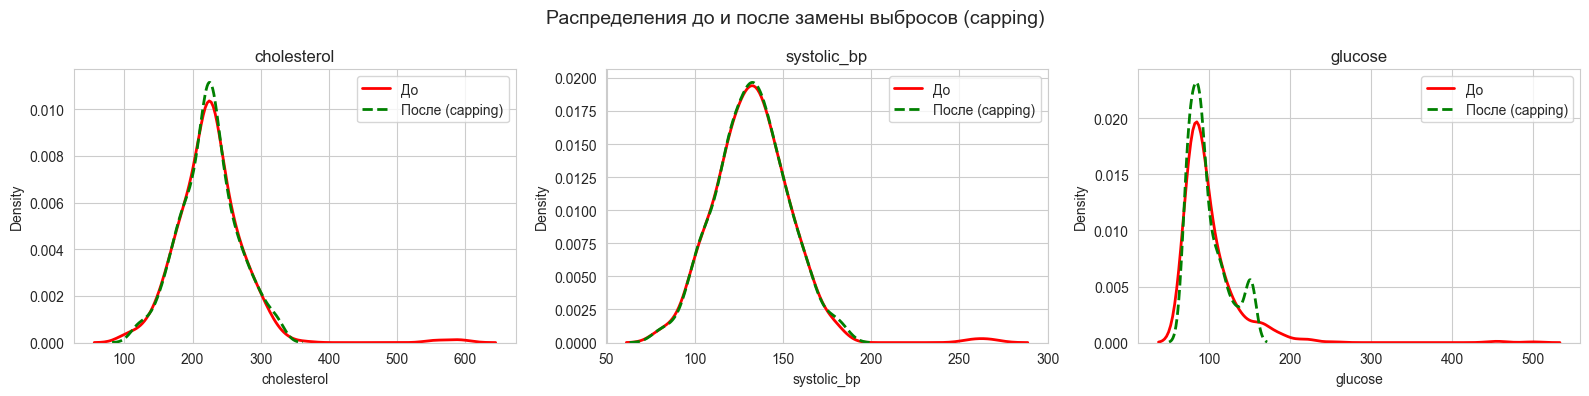


Размер данных сохранён: 600 строк (ни одна не удалена!)


In [26]:
df_capped = df_imp.copy()

for col in outlier_cols:
    lower, upper, mask = detect_outliers_iqr(df_capped[col])
    n_outliers = mask.sum()
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    print(f'{col}: заменено {n_outliers} выбросов (границы: [{lower:.1f}, {upper:.1f}])')

# Визуализация до и после замены
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    sns.kdeplot(df_imp[col], ax=ax, label='До', linewidth=2, color='red')
    sns.kdeplot(df_capped[col], ax=ax, label='После (capping)', linewidth=2, 
                linestyle='--', color='green')
    ax.set_title(f'{col}', fontsize=12)
    ax.legend()
plt.suptitle('Распределения до и после замены выбросов (capping)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nРазмер данных сохранён: {len(df_capped)} строк (ни одна не удалена!)')

---
## 6. Обработка нестандартного признака (дата-время)

Признак `admission_date` не является ни числовым, ни категориальным. Из него нужно извлечь полезные признаки.

In [27]:
df_dt = df_imp.copy()
print(f'Тип admission_date: {df_dt["admission_date"].dtype}')
display(df_dt[['admission_date']].head())

Тип admission_date: datetime64[us]


,admission_date
0,2022-11-13
1,2023-08-07
2,2023-06-24
3,2022-11-08
4,2022-09-01


### 6.1 Извлечение стандартных компонентов даты

In [28]:
df_dt['adm_year'] = df_dt['admission_date'].dt.year
df_dt['adm_month'] = df_dt['admission_date'].dt.month
df_dt['adm_day'] = df_dt['admission_date'].dt.day
df_dt['adm_dayofweek'] = df_dt['admission_date'].dt.dayofweek  # 0=Mon ... 6=Sun
df_dt['adm_quarter'] = df_dt['admission_date'].dt.quarter
df_dt['adm_is_weekend'] = (df_dt['adm_dayofweek'] >= 5).astype(int)

dt_features = ['adm_year', 'adm_month', 'adm_day', 'adm_dayofweek', 'adm_quarter', 'adm_is_weekend']
print('Извлечённые признаки из даты госпитализации:')
display(df_dt[['admission_date'] + dt_features].head(10))

Извлечённые признаки из даты госпитализации:


,admission_date,adm_year,adm_month,adm_day,adm_dayofweek,adm_quarter,adm_is_weekend
0,2022-11-13,2022,11,13,6,4,1
1,2023-08-07,2023,8,7,0,3,0
2,2023-06-24,2023,6,24,5,2,1
3,2022-11-08,2022,11,8,1,4,0
4,2022-09-01,2022,9,1,3,3,0
5,2022-08-20,2022,8,20,5,3,1
6,2023-07-20,2023,7,20,3,3,0
7,2022-02-08,2022,2,8,1,1,0
8,2022-01-10,2022,1,10,0,1,0
9,2023-08-04,2023,8,4,4,3,0


### 6.2 Циклическое кодирование (отображение на круг) для месяца и дня недели

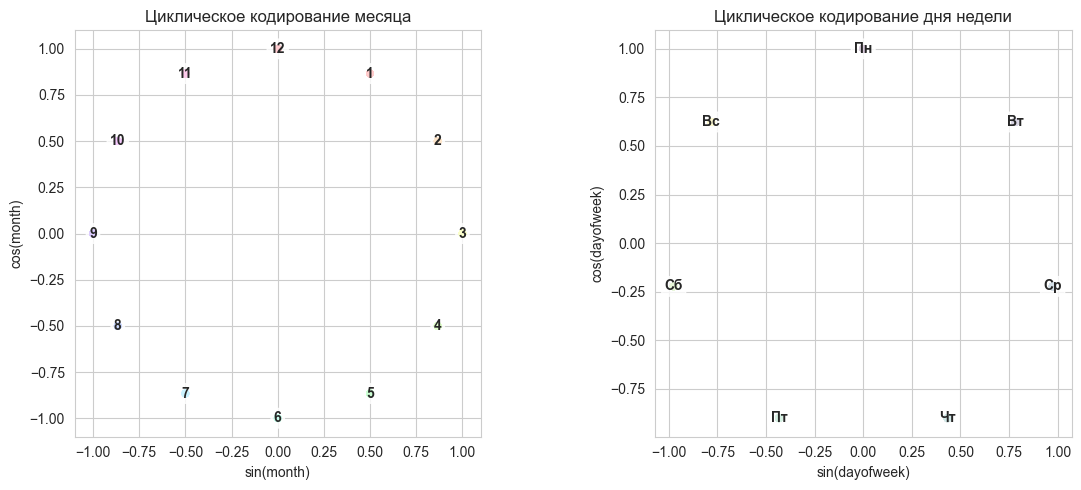

Циклические признаки:


,adm_month,month_sin,month_cos,adm_dayofweek,dow_sin,dow_cos
0,11,-5.000000e-01,8.660254e-01,6,-0.781831,0.623490
1,8,-8.660254e-01,-5.000000e-01,0,0.000000,1.000000
2,6,1.224647e-16,-1.000000e+00,5,-0.974928,-0.222521
3,11,-5.000000e-01,8.660254e-01,1,0.781831,0.623490
4,9,-1.000000e+00,-1.836970e-16,3,0.433884,-0.900969
5,8,-8.660254e-01,-5.000000e-01,5,-0.974928,-0.222521
6,7,-5.000000e-01,-8.660254e-01,3,0.433884,-0.900969
7,2,8.660254e-01,5.000000e-01,1,0.781831,0.623490
8,1,5.000000e-01,8.660254e-01,0,0.000000,1.000000
9,8,-8.660254e-01,-5.000000e-01,4,-0.433884,-0.900969


In [29]:
# Месяц (период T=12)
df_dt['month_sin'] = np.sin(2 * np.pi * df_dt['adm_month'] / 12)
df_dt['month_cos'] = np.cos(2 * np.pi * df_dt['adm_month'] / 12)

# День недели (период T=7)
df_dt['dow_sin'] = np.sin(2 * np.pi * df_dt['adm_dayofweek'] / 7)
df_dt['dow_cos'] = np.cos(2 * np.pi * df_dt['adm_dayofweek'] / 7)

# Визуализация циклического кодирования
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_dt['month_sin'], df_dt['month_cos'], 
                c=df_dt['adm_month'], cmap='hsv', alpha=0.5, s=20)
axes[0].set_xlabel('sin(month)')
axes[0].set_ylabel('cos(month)')
axes[0].set_title('Циклическое кодирование месяца', fontsize=12)
axes[0].set_aspect('equal')
# Подписи месяцев
for m in range(1, 13):
    x = np.sin(2 * np.pi * m / 12)
    y = np.cos(2 * np.pi * m / 12)
    axes[0].annotate(str(m), (x, y), fontsize=10, fontweight='bold',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

axes[1].scatter(df_dt['dow_sin'], df_dt['dow_cos'], 
                c=df_dt['adm_dayofweek'], cmap='viridis', alpha=0.5, s=20)
axes[1].set_xlabel('sin(dayofweek)')
axes[1].set_ylabel('cos(dayofweek)')
axes[1].set_title('Циклическое кодирование дня недели', fontsize=12)
axes[1].set_aspect('equal')
days_ru = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
for d in range(7):
    x = np.sin(2 * np.pi * d / 7)
    y = np.cos(2 * np.pi * d / 7)
    axes[1].annotate(days_ru[d], (x, y), fontsize=10, fontweight='bold',
                     ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

cyclic_cols = ['month_sin', 'month_cos', 'dow_sin', 'dow_cos']
print('Циклические признаки:')
display(df_dt[['adm_month', 'month_sin', 'month_cos', 'adm_dayofweek', 'dow_sin', 'dow_cos']].head(10))

### 6.3 Временной интервал от начала наблюдений

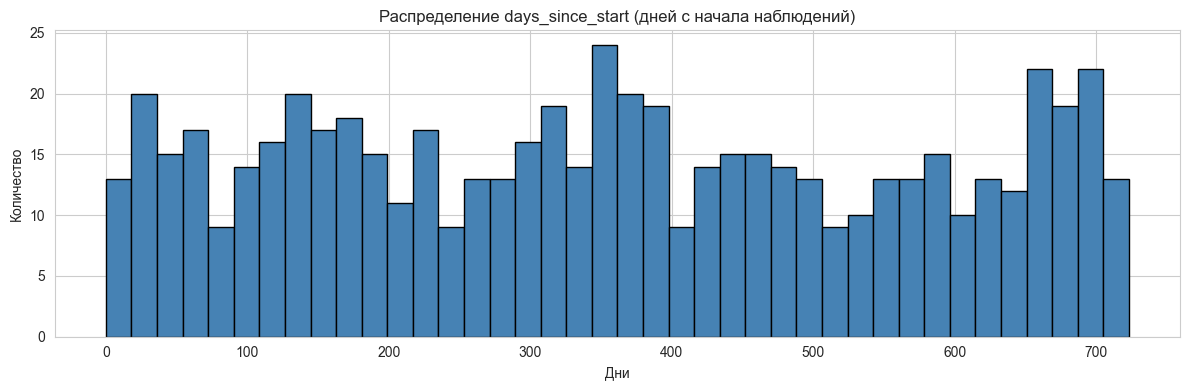

Мин: 0, Макс: 723


In [30]:
ref_date = df_dt['admission_date'].min()
df_dt['days_since_start'] = (df_dt['admission_date'] - ref_date).dt.days

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df_dt['days_since_start'], bins=40, color='steelblue', edgecolor='black')
ax.set_title('Распределение days_since_start (дней с начала наблюдений)', fontsize=12)
ax.set_xlabel('Дни')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

print(f'Мин: {df_dt["days_since_start"].min()}, Макс: {df_dt["days_since_start"].max()}')

---
## 7. Отбор признаков

Для отбора признаков используем датасет **Breast Cancer** из sklearn (медицинская тематика, 30 числовых признаков, задача классификации).

In [31]:
bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = bc.target  # 0 = malignant, 1 = benign

print(f'Размер: {X_bc.shape}')
print(f'Целевая переменная: {np.unique(y_bc, return_counts=True)}')
print(f'Признаки: {list(bc.feature_names)}')
display(X_bc.describe().round(2))

Размер: (569, 30)
Целевая переменная: (array([0, 1]), array([212, 357]))
Признаки: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


### 7.1 Filter method — SelectKBest (mutual information)

SelectKBest (mutual information, k=10):
Отобранные признаки: ['worst perimeter', 'worst area', 'worst radius', 'mean concave points', 'worst concave points', 'mean perimeter', 'mean concavity', 'mean radius', 'mean area', 'area error']


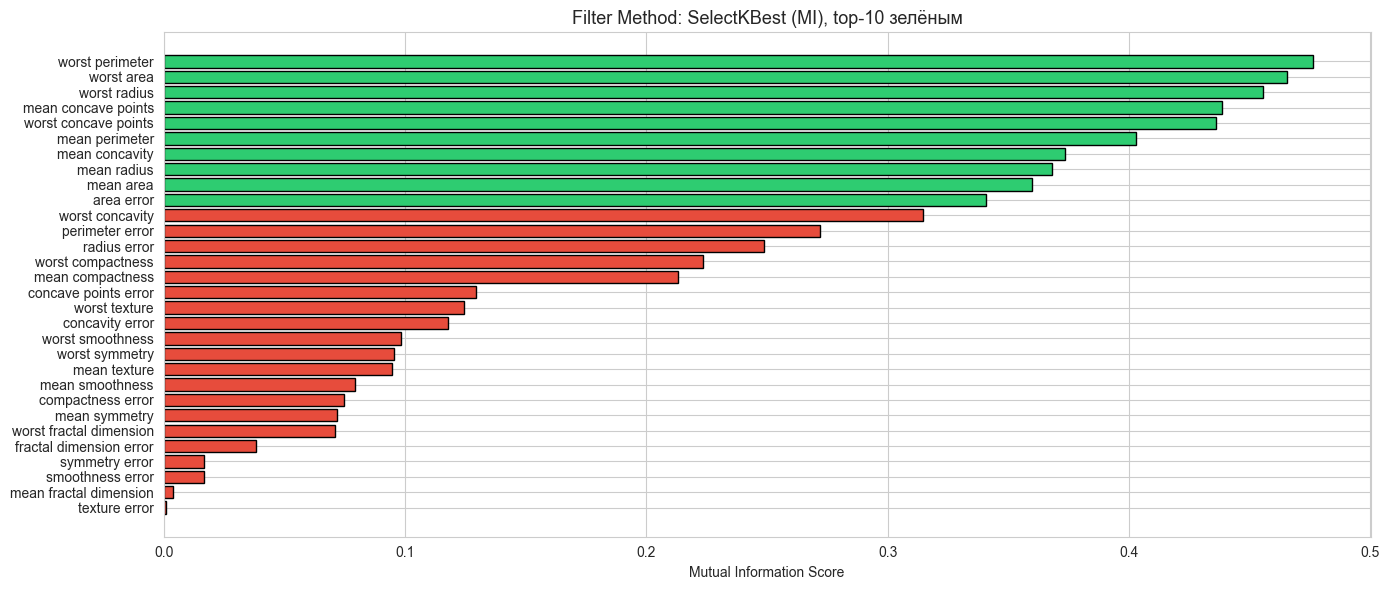

In [32]:
# SelectKBest с mutual_info_classif
k_best = 10
selector_filter = SelectKBest(score_func=mutual_info_classif, k=k_best)
selector_filter.fit(X_bc, y_bc)

# Результаты
mi_scores = pd.DataFrame({
    'Признак': bc.feature_names,
    'MI Score': selector_filter.scores_,
    'Отобран': selector_filter.get_support()
}).sort_values('MI Score', ascending=False)

print(f'SelectKBest (mutual information, k={k_best}):')
print(f'Отобранные признаки: {list(mi_scores[mi_scores["Отобран"]]["Признак"])}')

# Визуализация
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if s else '#e74c3c' for s in mi_scores['Отобран']]
ax.barh(mi_scores['Признак'], mi_scores['MI Score'], color=colors, edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title(f'Filter Method: SelectKBest (MI), top-{k_best} зелёным', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.2 Wrapper method — RFE (Recursive Feature Elimination)

RFE (Recursive Feature Elimination) с LogisticRegression:
Отобранные признаки: ['mean concave points', 'compactness error', 'area error', 'radius error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points', 'worst concavity']


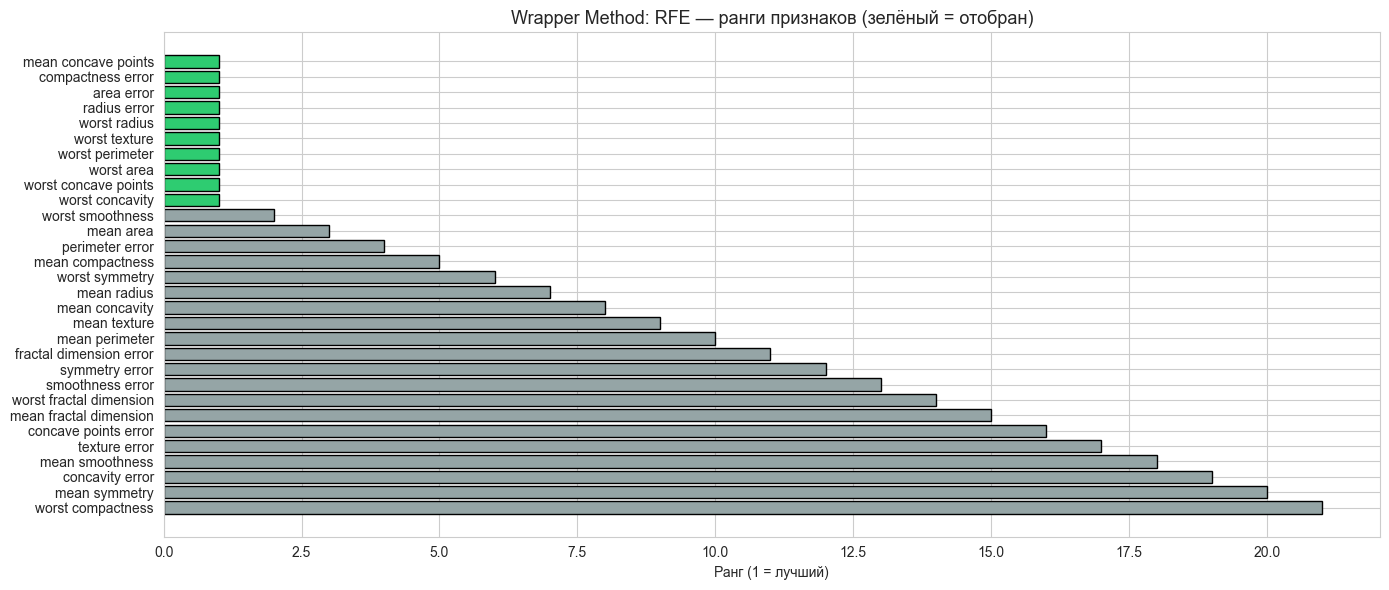

In [33]:
# RFE с логистической регрессией
estimator_rfe = LogisticRegression(max_iter=5000, random_state=42)
rfe_selector = RFE(estimator=estimator_rfe, n_features_to_select=10, step=1)

# Масштабируем перед RFE (важно для логистической регрессии)
scaler_rfe = StandardScaler()
X_bc_scaled = scaler_rfe.fit_transform(X_bc)

rfe_selector.fit(X_bc_scaled, y_bc)

rfe_results = pd.DataFrame({
    'Признак': bc.feature_names,
    'Ранг': rfe_selector.ranking_,
    'Отобран': rfe_selector.support_
}).sort_values('Ранг')

print('RFE (Recursive Feature Elimination) с LogisticRegression:')
print(f'Отобранные признаки: {list(rfe_results[rfe_results["Отобран"]]["Признак"])}')

# Визуализация рангов
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if s else '#95a5a6' for s in rfe_results['Отобран']]
ax.barh(rfe_results['Признак'], rfe_results['Ранг'], color=colors, edgecolor='black')
ax.set_xlabel('Ранг (1 = лучший)')
ax.set_title('Wrapper Method: RFE — ранги признаков (зелёный = отобран)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.3 Embedded method — SelectFromModel (Random Forest)

Embedded: SelectFromModel (RandomForest):
Порог: mean importance = 0.0333
Отобранные признаки: ['worst perimeter', 'worst area', 'worst concave points', 'mean concave points', 'worst radius', 'mean area', 'mean perimeter', 'mean concavity', 'mean radius', 'worst concavity']


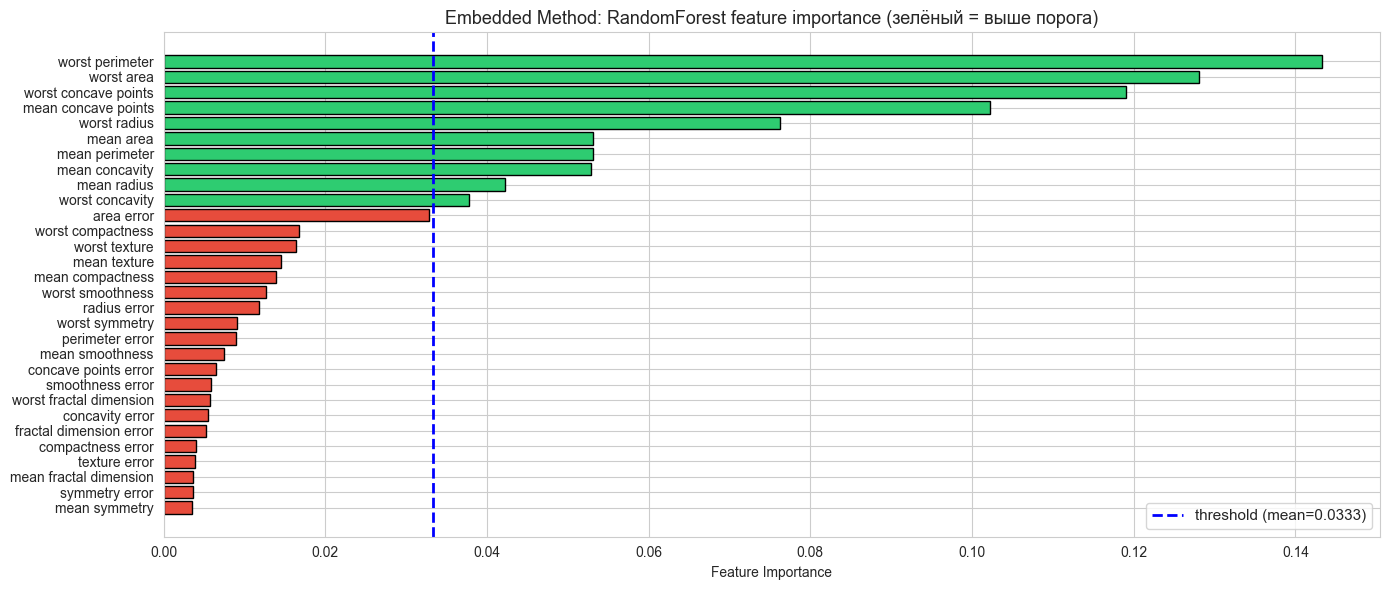

In [34]:
# Embedded: RandomForest feature importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_bc, y_bc)

embedded_selector = SelectFromModel(rf, prefit=True)
selected_mask = embedded_selector.get_support()

emb_results = pd.DataFrame({
    'Признак': bc.feature_names,
    'Важность': rf.feature_importances_,
    'Отобран': selected_mask
}).sort_values('Важность', ascending=False)

print('Embedded: SelectFromModel (RandomForest):')
print(f'Порог: mean importance = {rf.feature_importances_.mean():.4f}')
print(f'Отобранные признаки: {list(emb_results[emb_results["Отобран"]]["Признак"])}')

# Визуализация
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if s else '#e74c3c' for s in emb_results['Отобран']]
ax.barh(emb_results['Признак'], emb_results['Важность'], color=colors, edgecolor='black')
ax.axvline(x=rf.feature_importances_.mean(), color='blue', linestyle='--', 
           linewidth=2, label=f'threshold (mean={rf.feature_importances_.mean():.4f})')
ax.set_xlabel('Feature Importance')
ax.set_title('Embedded Method: RandomForest feature importance (зелёный = выше порога)', fontsize=13)
ax.legend(fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.4 Сравнение трёх методов отбора

In [35]:
# Сравнительная таблица
comparison = pd.DataFrame({
    'Признак': bc.feature_names,
    'Filter (MI)': selector_filter.get_support(),
    'Wrapper (RFE)': rfe_selector.support_,
    'Embedded (RF)': selected_mask
})
comparison['Сумма методов'] = (comparison['Filter (MI)'].astype(int) + 
                                comparison['Wrapper (RFE)'].astype(int) + 
                                comparison['Embedded (RF)'].astype(int))
comparison = comparison.sort_values('Сумма методов', ascending=False)

print('Сравнение методов отбора (True = признак отобран):')
display(comparison.style.map(
    lambda v: 'background-color: #d4edda' if v == True else 
              ('background-color: #f8d7da' if v == False else ''),
    subset=['Filter (MI)', 'Wrapper (RFE)', 'Embedded (RF)']
))

Сравнение методов отбора (True = признак отобран):


,Признак,Filter (MI),Wrapper (RFE),Embedded (RF),Сумма методов
7,mean concave points,True,True,True,3
20,worst radius,True,True,True,3
22,worst perimeter,True,True,True,3
23,worst area,True,True,True,3
27,worst concave points,True,True,True,3
0,mean radius,True,False,True,2
3,mean area,True,False,True,2
13,area error,True,True,False,2
6,mean concavity,True,False,True,2
26,worst concavity,False,True,True,2


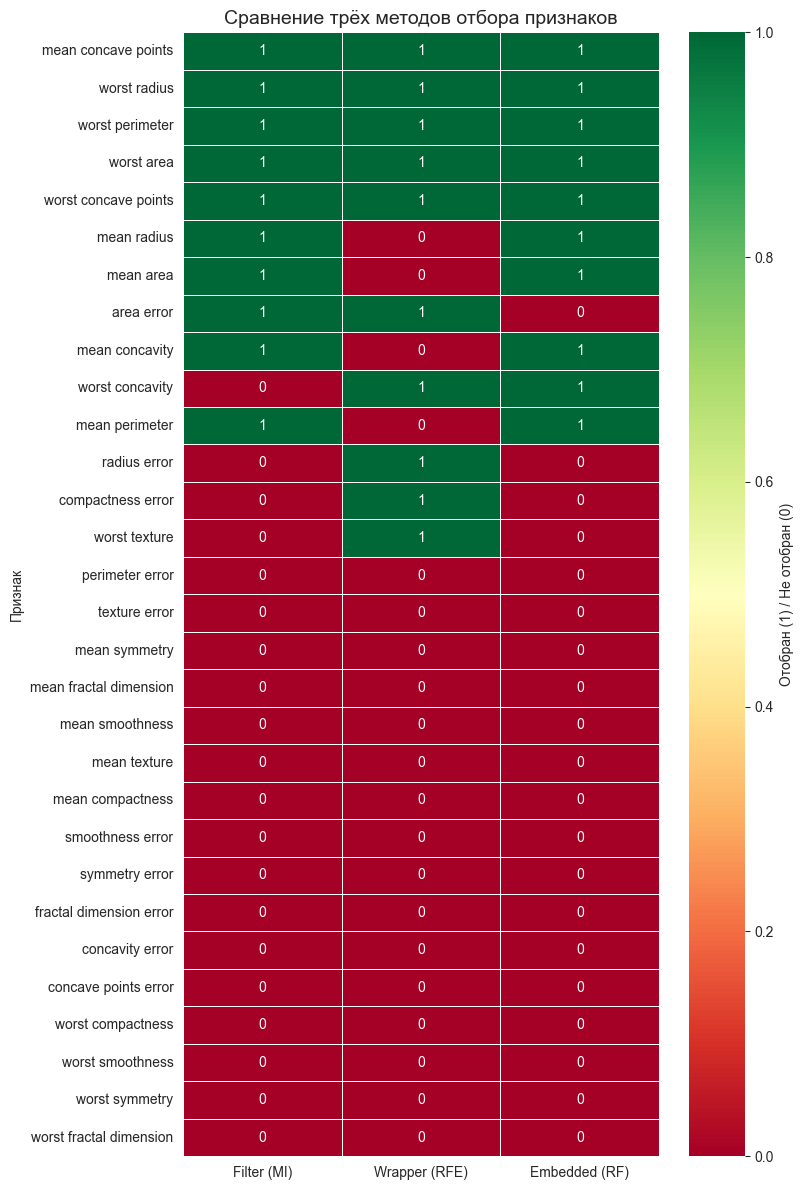

In [36]:
# Venn-подобная визуализация: heatmap
heat_data = comparison.set_index('Признак')[['Filter (MI)', 'Wrapper (RFE)', 'Embedded (RF)']].astype(int)

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(heat_data, annot=True, cmap='RdYlGn', linewidths=0.5, 
            cbar_kws={'label': 'Отобран (1) / Не отобран (0)'}, ax=ax, fmt='d')
ax.set_title('Сравнение трёх методов отбора признаков', fontsize=14)
plt.tight_layout()
plt.show()

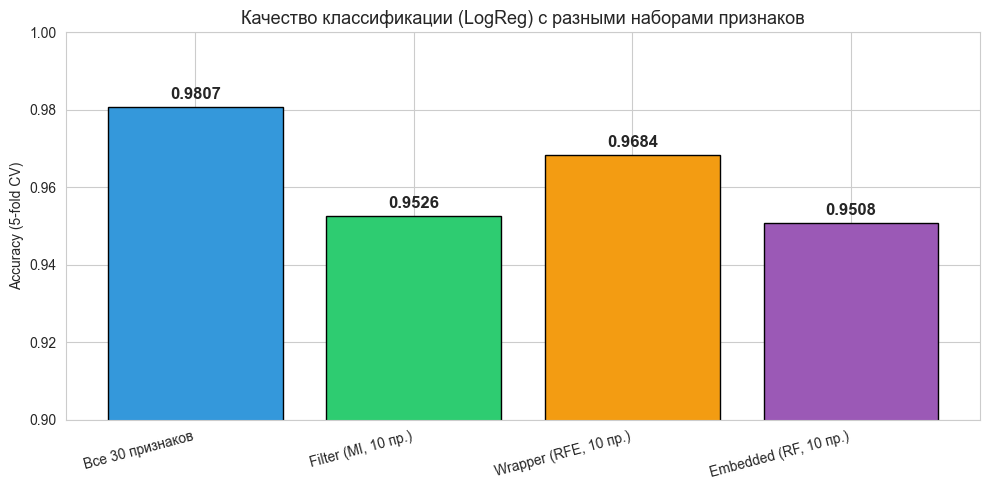

Результаты (accuracy):
  Все 30 признаков: 0.9807
  Filter (MI, 10 пр.): 0.9526
  Wrapper (RFE, 10 пр.): 0.9684
  Embedded (RF, 10 пр.): 0.9508


In [37]:
# Оценка качества классификации на отобранных признаках vs все признаки
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=5000, random_state=42)
scaler = StandardScaler()

results_cv = {}

# Все признаки
X_all_sc = scaler.fit_transform(X_bc)
scores_all = cross_val_score(clf, X_all_sc, y_bc, cv=5, scoring='accuracy')
results_cv['Все 30 признаков'] = scores_all.mean()

# Filter
X_filter = X_bc.iloc[:, selector_filter.get_support()]
X_filter_sc = scaler.fit_transform(X_filter)
scores_filter = cross_val_score(clf, X_filter_sc, y_bc, cv=5, scoring='accuracy')
results_cv[f'Filter (MI, {X_filter.shape[1]} пр.)'] = scores_filter.mean()

# Wrapper
X_wrapper = X_bc.iloc[:, rfe_selector.support_]
X_wrapper_sc = scaler.fit_transform(X_wrapper)
scores_wrapper = cross_val_score(clf, X_wrapper_sc, y_bc, cv=5, scoring='accuracy')
results_cv[f'Wrapper (RFE, {X_wrapper.shape[1]} пр.)'] = scores_wrapper.mean()

# Embedded
X_embedded = X_bc.iloc[:, selected_mask]
X_embedded_sc = scaler.fit_transform(X_embedded)
scores_embedded = cross_val_score(clf, X_embedded_sc, y_bc, cv=5, scoring='accuracy')
results_cv[f'Embedded (RF, {X_embedded.shape[1]} пр.)'] = scores_embedded.mean()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar(results_cv.keys(), results_cv.values(), color=colors_bar, edgecolor='black')
for bar, val in zip(bars, results_cv.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Качество классификации (LogReg) с разными наборами признаков', fontsize=13)
ax.set_ylim(0.9, 1.0)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print('Результаты (accuracy):')
for k, v in results_cv.items():
    print(f'  {k}: {v:.4f}')

---
## Итоги

| Задача | Что сделано | Датасет |
|--------|------------|--------|
| 1. Пропуски | Удаление строк, заполнение mean/median (SimpleImputer), KNN-импьютация, мода для категорий | Кардиологический |
| 2. Кодирование | Label Encoding (gender), Ordinal Encoding (smoking), One-Hot Encoding (blood_type, chest_pain) | Кардиологический |
| 3. Нормализация | Log, Sqrt, Box-Cox, Yeo-Johnson — с тестом Шапиро-Уилка и Q-Q plot | Кардиологический |
| 4. Масштабирование | StandardScaler, MinMaxScaler, RobustScaler — 3 способа | Кардиологический |
| 5. Выбросы | Обнаружение (IQR), удаление, замена (capping/winsorization) | Кардиологический |
| 6. Нестандартный признак | Дата → год, месяц, день, квартал, выходной, циклическое кодирование (sin/cos) | Кардиологический |
| 7. Отбор признаков | Filter (SelectKBest + MI), Wrapper (RFE), Embedded (RandomForest + SelectFromModel) | Breast Cancer |